In [59]:
# 3rd party
import numpy as np
import matplotlib.pyplot as plt
#from numpy.core.defchararray import startswith



#from astropy.io import fits
#from astropy.visualization import make_lupton_rgb

In [60]:
DEF_ACCESS_URL = "https://datalab.noirlab.edu/sia/nsc_dr2"
service = sia.SIAService(DEF_ACCESS_URL)

In [61]:
fov = 0.04*1.5
ra = 53.53378
dec = -28.01815
band = 'i'
imgTable = service.search((ra,dec), (fov/np.cos(dec*np.pi/180), fov), verbosity=2).to_table()

In [62]:
table = imgTable[(imgTable['prodtype'] == 'image') & (imgTable['obs_bandpass']==band) & \
    (np.char.find(np.ma.filled(imgTable['object'].astype(str), fill_value='none'),'DES')!=-1)]
row = table[np.argmin(table['seeing'])]

In [63]:
url = row['access_url']
filename = download_file(url,cache=True,show_progress=False,timeout=120)
hdu = fits.open(filename)[0]
image = hdu.data
hdr = hdu.header
wcs = WCS(hdr)

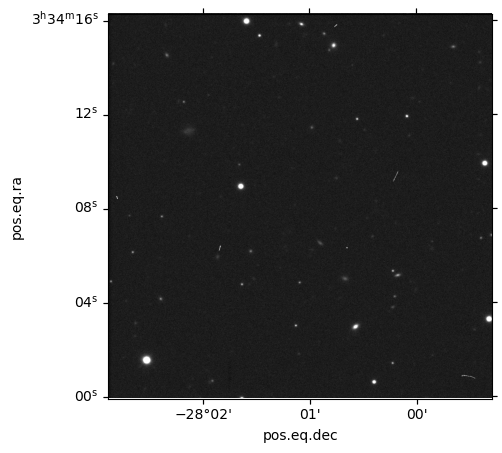

In [66]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1, projection=wcs)
ax.imshow(image, cmap='gray', vmin=image.min(), vmax=image.min()+(image.max()-image.min())/100.)
#ax.scatter(df['ra'], df['dec'], transform=ax.get_transform('icrs'), s=1000./(df['gmag']-12), 
#           edgecolor='green', facecolor='none', linewidths=3)
plt.show()

In [70]:
from pathlib import Path

from astropy.coordinates import SkyCoord
from astropy import units as u

#from astroquery_updated.esa.euclid import Euclid
from ugali.utils import healpix

# https://astroquery.readthedocs.io/en/latest/esa/euclid/euclid.html#mer-cutouts

def euclidCutout(output_file, ra, dec, cutout_radius):
    """
    Retrieves a FITS image cutout from the Euclid Q1 VIS mosaic for a specific coordinate.

    This function queries the Euclid TAP server for 'VIS' instrument mosaic products 
    that overlap with the specified Right Ascension and Declination. It requires exactly 
    one overlapping file to proceed, and downloads the resulting spatial cutout.

    Parameters
    ----------
    output_file : str
        The local destination file path and name for the downloaded FITS cutout 
        (e.g., 'my_target_cutout.fits').
    ra : float
        Right Ascension of the target center in decimal degrees (ICRS).
    dec : float
        Declination of the target center in decimal degrees (ICRS).
    cutout_radius : float
        The requested radius of the image cutout in arcseconds.

    Raises
    ------
    ValueError
        If the spatial query returns zero files, or more than one overlapping file.

    Notes
    -----
    Requires `astroquery.esa.euclid`, `astropy.coordinates.SkyCoord`, and `astropy.units`.
    """

    coord = SkyCoord(ra=ra, dec=dec, unit='deg', frame='icrs')
    
    # Step 1: Query file paths
    radius   = 0.5 / 60.
    query    = f"""
    SELECT 
    file_name, file_path, datalabs_path, instrument_name, filter_name, ra, dec, creation_date, product_type, patch_id_list, tile_index 
    FROM 
    q1.mosaic_product 
    WHERE 
    instrument_name='VIS' AND INTERSECTS(CIRCLE({ra}, {dec}, {radius}), fov)=1 
    ORDER BY 
    file_name
    """
    results = Euclid.launch_job_async(query).get_results()
    if len(results) > 1:
        #breakpoint()
        #raise ValueError("Expected 1 file and got %i files"%(len(results)))
        print("Expected 1 file and got %i files"%(len(results)))

        # Select the closest file
        coord_results = SkyCoord(ra=results['ra'], dec=results['dec'], unit='deg', frame='icrs')
        results = results[np.argmin(coord.separation(coord_results))]
        file_path  = f"{results['file_path']}/{results['file_name']}"
    elif len(results) == 1:
        file_path  = f"{results['file_path'][0]}/{results['file_name'][0]}"
    else:
        print("Expected 1 file and got %i files"%(len(results)))
        return None

    # Step 2: Get cutout
    cutout_radius = cutout_radius * u.arcsec
    Euclid.get_cutout(
        file_path=file_path,
        coordinate=coord,
        radius=cutout_radius, 
        output_file=output_file,
        verbose=True,
	)

ModuleNotFoundError: No module named 'ugali'